#### Load dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load Data
original_dataset = pd.read_csv("googleplaystore.csv")
df = original_dataset.copy()

In [2]:
df.shape

(10841, 13)

##### => This dataset contains 10357 rows and 13 columns

In [3]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


#### Data Preprocessing and Cleaning

In [4]:
# Data Cleaning
# Drop the anomalous row if it exists (where Category is 1.9)
if df[df['Category'] == '1.9'].shape[0] > 0:
    df = df.drop(df[df['Category'] == '1.9'].index)

In [5]:
# Reviews to numeric
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Installs: remove '+' and ','
df['Installs'] = df['Installs'].str.replace('+', '', regex=False).str.replace(',', '', regex=False)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Price: remove '$'
df['Price'] = df['Price'].str.replace('$', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

In [6]:
# Size: convert M and k to numeric
def convert_size(size):
    if isinstance(size, str):
        if 'M' in size:
            return float(size.replace('M', '')) * 1024 * 1024
        elif 'k' in size:
            return float(size.replace('k', '')) * 1024
        elif 'Varies with device' in size:
            return np.nan
    return pd.to_numeric(size, errors='coerce')

df['Size'] = df['Size'].apply(convert_size)

#### Handle Missing values

In [7]:
# Handle Missing Values
df['Rating'] = df['Rating'].fillna(df['Rating'].median())
df['Size'] = df['Size'].fillna(df['Size'].median())
df['Type'] = df['Type'].fillna(df['Type'].mode()[0])
df['Current Ver'] = df['Current Ver'].fillna('Varies with device')
df['Android Ver'] = df['Android Ver'].fillna('Varies with device')

In [8]:
# Drop duplicates
df.drop_duplicates(inplace=True)

#### Exploratory Data Analysis

Cleaning and EDA completed. Plots saved.


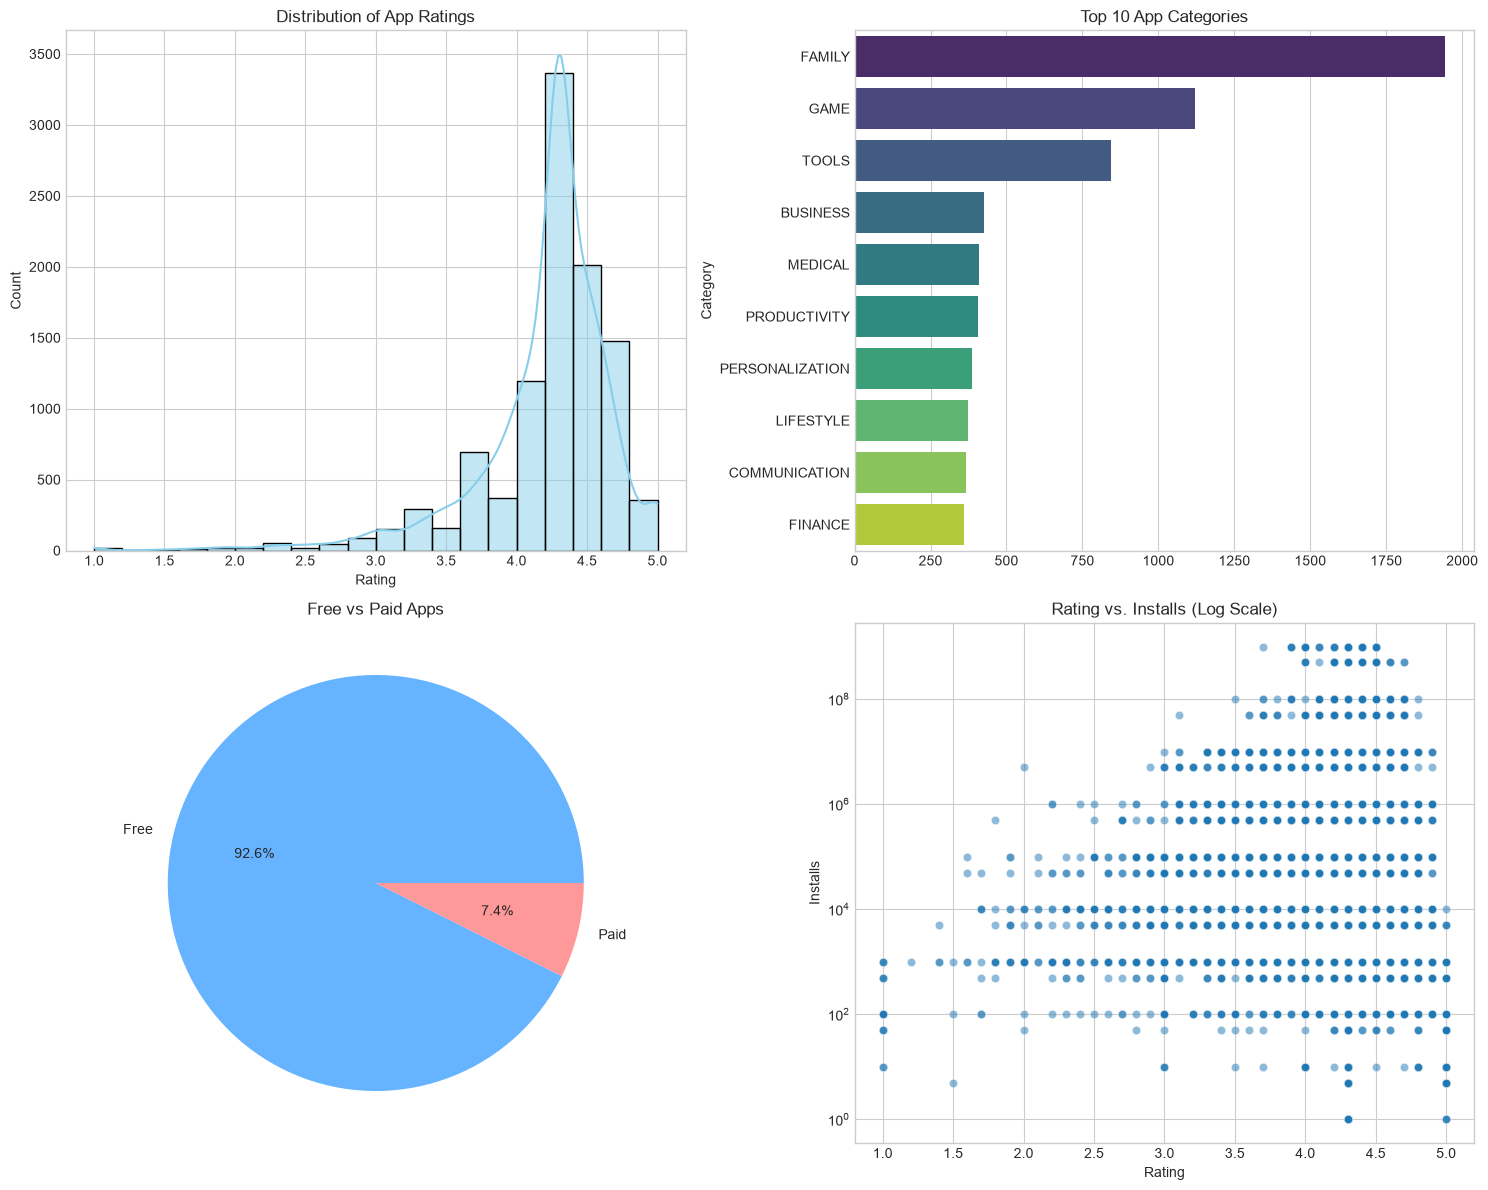

In [15]:
# EDA Visualizations
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Distribution of Ratings
sns.histplot(df['Rating'], bins=20, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of App Ratings')


# Top 10 Categories by Count
top_categories = df['Category'].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Top 10 App Categories')


# Type (Free vs Paid)
type_counts = df['Type'].value_counts()
axes[1, 0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
axes[1, 0].set_title('Free vs Paid Apps')


# Rating vs. Installs (Log Scale for Installs)
sns.scatterplot(x='Rating', y='Installs', data=df, ax=axes[1, 1], alpha=0.5)
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Rating vs. Installs (Log Scale)')

plt.tight_layout()
print("Cleaning and EDA completed. Plots saved.")

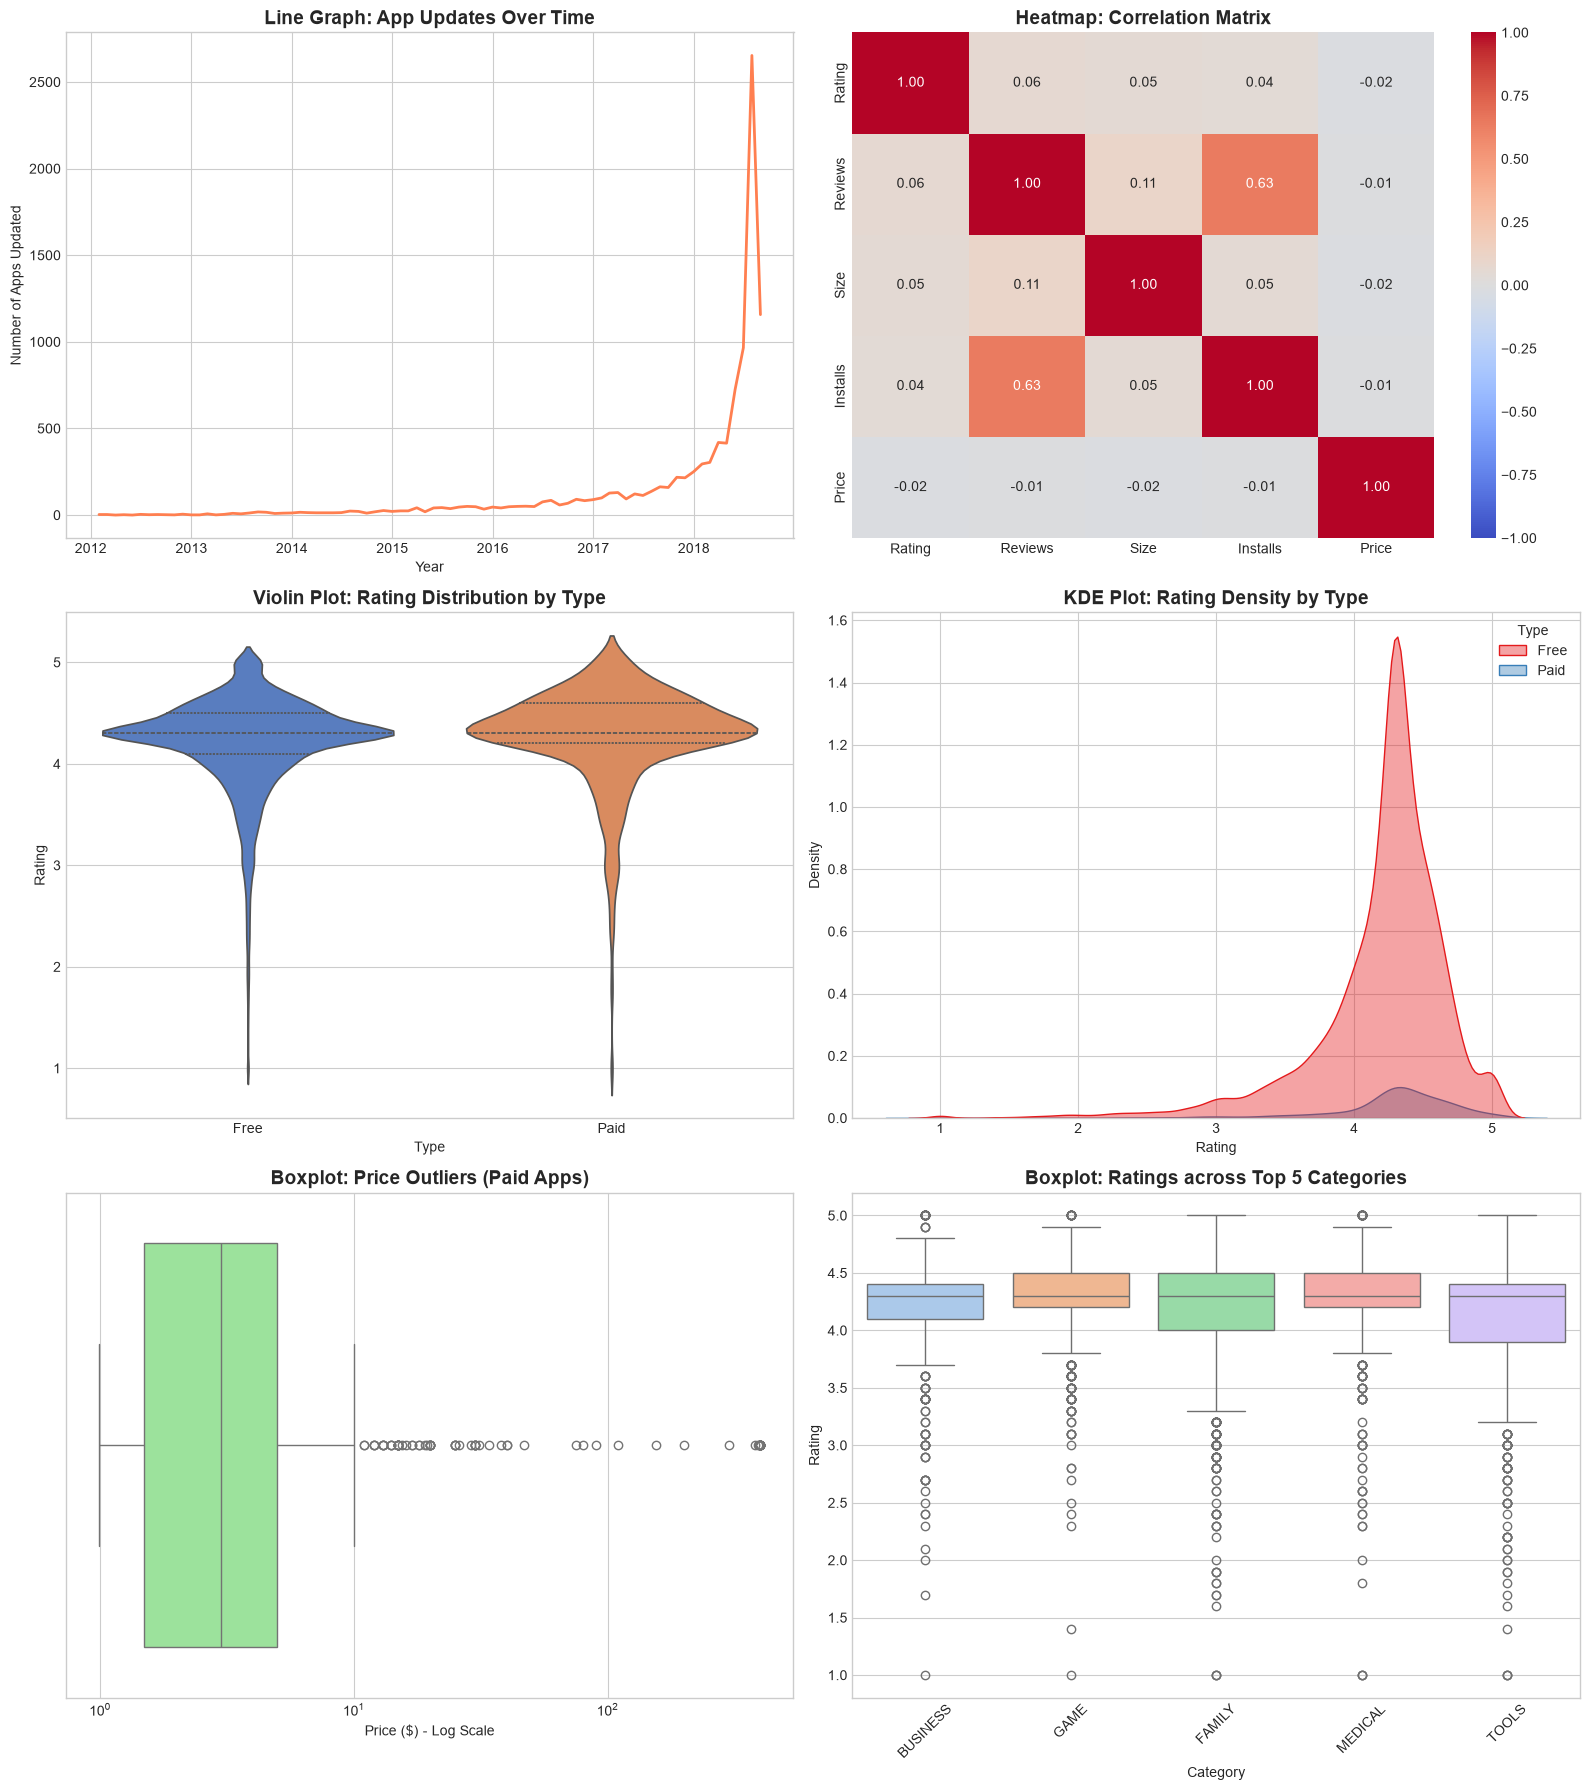

In [16]:
# Remove anomaly
df = df[df['Category'] != '1.9']

# Parse Dates for the line graph
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

# Setup Plotting
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# --- Line Graph (Updates over time) ---
# Resample by month to see the trend of app updates
updates_per_month = df.set_index('Last Updated').resample('ME').size()
updates_per_month = updates_per_month[updates_per_month.index > '2012-01-01'] # Filter out sparse early years for clarity

axes[0, 0].plot(updates_per_month.index, updates_per_month.values, color='coral', linewidth=2)
axes[0, 0].set_title('Line Graph: App Updates Over Time', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Number of Apps Updated')
axes[0, 0].set_xlabel('Year')

# --- Correlation Heatmap ---
numeric_cols = df[['Rating', 'Reviews', 'Size', 'Installs', 'Price']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', ax=axes[0, 1], fmt=".2f", vmin=-1, vmax=1)
axes[0, 1].set_title('Heatmap: Correlation Matrix', fontsize=14, fontweight='bold')

# --- Violin Plot ---
sns.violinplot(x='Type', y='Rating', data=df, ax=axes[1, 0], palette='muted', inner='quartile')
axes[1, 0].set_title('Violin Plot: Rating Distribution by Type', fontsize=14, fontweight='bold')

# --- KDE Plot ---
sns.kdeplot(data=df, x='Rating', hue='Type', fill=True, ax=axes[1, 1], palette='Set1', alpha=0.4)
axes[1, 1].set_title('KDE Plot: Rating Density by Type', fontsize=14, fontweight='bold')

# --- Boxplot (Outliers in Price) ---
# Filter for Paid apps only, and use log scale to visualize extreme outliers
sns.boxplot(x='Price', data=df[df['Type'] == 'Paid'], ax=axes[2, 0], color='lightgreen')
axes[2, 0].set_title('Boxplot: Price Outliers (Paid Apps)', fontsize=14, fontweight='bold')
axes[2, 0].set_xscale('log') 
axes[2, 0].set_xlabel('Price ($) - Log Scale')

# Boxplot (Rating by Top 5 Categories) ---
top_cats = df['Category'].value_counts().head(5).index
sns.boxplot(x='Category', y='Rating', data=df[df['Category'].isin(top_cats)], ax=axes[2, 1], palette='pastel')
axes[2, 1].set_title('Boxplot: Ratings across Top 5 Categories', fontsize=14, fontweight='bold')
axes[2, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Feature Engineering
# Let's extract numerical and categorical columns
X = df[['Category', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating']]
y = df['Rating']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define columns
numeric_features = ['Reviews', 'Size', 'Installs', 'Price']
categorical_features = ['Category', 'Type', 'Content Rating']

# Log transformation function for highly skewed data
def log_transform(x):
    return np.log1p(x)

# Preprocessing for numeric data
numeric_transformer = Pipeline(steps=[
    ('log', FunctionTransformer(log_transform, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # Create and evaluate pipeline
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('model', model)])
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MSE': mse, 'R2': r2}

print(results)

{'Linear Regression': {'MSE': 0.2263182290597934, 'R2': 0.09225768222838804}, 'Random Forest': {'MSE': 0.23323949284374754, 'R2': 0.06449710785814866}}


In [12]:
X.isnull().sum()

Category          0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
dtype: int64

In [14]:
df.shape

(10357, 13)